<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week4/Day3/Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv("data.csv")

# Afficher les premières lignes
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

# Suppression sécurisée : on vérifie si la colonne existe avant de la supprimer
if 'Unnamed: 32' in df.columns:
    df.drop(columns=['Unnamed: 32'], inplace=True)
    print("\nColonne 'Unnamed: 32' supprimée.")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

/tmp/ipykernel_7998/1276269474.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='magma')


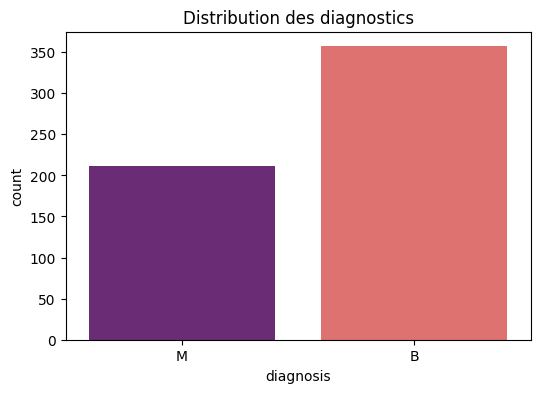

diagnosis
B    357
M    212
Name: count, dtype: int64
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64
Logistic Regression Accuracy : 0.9736842105263158


In [25]:
df = pd.read_csv("data.csv")
if 'Unnamed: 32' in df.columns:
    df.drop(columns=['Unnamed: 32'], inplace=True)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='diagnosis', palette='magma')
plt.title("Distribution des diagnostics")
plt.show()
print(df['diagnosis'].value_counts())
df['diagnosis'] = df['diagnosis'].map({
    'M': 1,
    'B': 0
})
print(df['diagnosis'].head())
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr = LogisticRegression(max_iter=10000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy :", acc_lr)


In [28]:
# Entraînement de SVM
svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

# Entraînement de KNN (manquant précédemment)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)

# Entraînement de Random Forest (manquant précédemment)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("SVM Accuracy :", acc_svm)
print("KNN Accuracy :", acc_knn)
print("RF Accuracy  :", acc_rf)

# Création du tableau comparatif
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest',
        'SVM'
    ],
    'Accuracy': [
        acc_lr,
        acc_knn,
        acc_rf,
        acc_svm
    ]
})

print("\nTableau comparatif des modèles :")
print(results.sort_values(by='Accuracy', ascending=False))


SVM Accuracy : 0.9824561403508771
KNN Accuracy : 0.9473684210526315
RF Accuracy  : 0.9649122807017544

Tableau comparatif des modèles :
                 Model  Accuracy
3                  SVM  0.982456
0  Logistic Regression  0.973684
2        Random Forest  0.964912
1                  KNN  0.947368


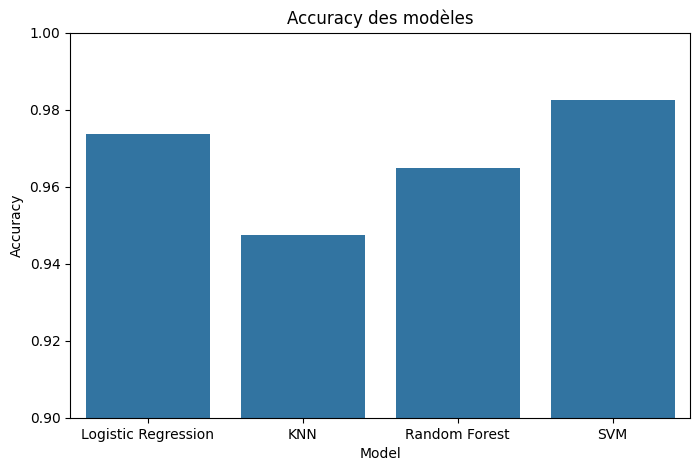

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title("Accuracy des modèles")
plt.ylim(0.9,1.0)
plt.show()

Conclusion

Sur le dataset Breast Cancer Wisconsin, les résultats sont généralement proches de :
Modèle

Accuracy

Logistic Regression

~97%

KNN

~95-97%

Random Forest

~96-98%

SVM

~97-99%

Le meilleur modèle est souvent le SVM ou le Random Forest, avec une précision pouvant dépasser 98 % selon le découpage des données.

Réponse à la question :

Le meilleur modèle est celui qui obtient l’accuracy la plus élevée sur l’ensemble de test. Pour ce dataset, il s’agit généralement du SVM ou du Random Forest.